# Experiment 3: Necessity Test - Silencing Experiment

**Purpose**
- Reproduce Shiu et al. (2024) Figure 1f-h
- Test which neurons are required for MN9 activation
- Method: Activate 21 Sugar GRNs continuously, silence neurons individually

**Configuration**
- Base activation: 21 Sugar GRNs (left hemisphere)
- Neurons to silence: Top 200 responsive neurons (from Exp1)
- Frequencies: 50, 60, 70, 80, 90, 100, 110, 120 Hz (8 frequencies)
- Trials: 10 per condition
- Batches: 8 batches (1 frequency each, 200 neurons)
- Workers: 4 (optimized from testing)

**Expected Runtime**
- Per batch: 200 neurons ÷ 4 workers × 33s ≈ **28 minutes**
- Total: 8 batches × 28 min ≈ **3.7 hours** (can run overnight)

**Memory Requirements**
- Peak: ~9GB (safe for 16GB system)
- Swap: 0GB (verified in mini test)

**Outputs**
- `results/exp3_necessity_test/exp3_complete_results.pkl`
- `results/exp3_necessity_test/necessary_neurons.npy` (for Venn diagram)
- `results/exp3_necessity_test/figures/` (heatmap, histogram, venn)

**Dependencies**
- Requires: `results/exp1_sugar_activation/top_200_neurons.npy`
- Optional: `results/exp2_sufficiency_test/sufficient_neurons.npy` (for Venn)

---

## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from time import time
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from brian2 import Hz, ms, start_scope

from joblib import Parallel, delayed
import gc

print("✅ Standard libraries imported")

✅ Standard libraries imported


In [2]:
# FlyWire tools
from caveclient import CAVEclient

print("Initializing CAVEclient...")
client = CAVEclient('flywire_fafb_public')
print("✅ Connected to FlyWire")

Initializing CAVEclient...
✅ Connected to FlyWire


In [3]:
# FlyLIF modules
from flylif.core.parameters import DEFAULT_PARAMS
from flylif.core.data_loader import load_simulation_data
from flylif.core.experiments import run_exp3_parallel
from flylif.utils.cave_utils import convert_neuron_list_cached
from flylif.utils.checkpoint import CheckpointManager
from flylif.utils.memory_utils import print_memory, check_memory_safe, memory_cleanup, MemoryMonitor

print("✅ FlyLIF modules imported")

✅ FlyLIF modules imported


In [4]:
# Auto-reload
%load_ext autoreload
%autoreload 2
print("✅ Auto-reload enabled")

✅ Auto-reload enabled


## 2. Configuration

In [5]:
BASE_DIR = Path.home() / 'mylibrary'/'connectome'/'lifmodel'

CONFIG = {
    'data_dir': BASE_DIR / 'data_783',
    'connections_file': 'proofread_connections_783.feather',
    'root_ids_file': 'proofread_root_ids_783.npy',
}

print("Configuration:")
print(f"  Data dir: {CONFIG['data_dir']}")

Configuration:
  Data dir: /Users/charlottel/mylibrary/connectome/lifmodel/data_783


### 缓存检查

In [6]:
# ===== Clean Brian2 Cache (Prevent Lock Issues) =====
import shutil
import os
from pathlib import Path
from datetime import datetime, timedelta

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'

if cache_dir.exists():
    # 检查lock文件年龄
    locks = list(cache_dir.glob('*.lock'))
    
    if locks:
        oldest_lock_age = max(time() - os.path.getmtime(f) for f in locks)
        
        # 如果有超过1小时的lock → 清除
        if oldest_lock_age > 3600:
            print(f"⚠️  Found {len(locks)} stale locks (oldest: {oldest_lock_age/3600:.1f}h)")
            print("   Cleaning Brian2 cache...")
            shutil.rmtree(cache_dir)
            cache_dir.mkdir(parents=True, exist_ok=True)
            print("   ✅ Cleaned")
        else:
            print(f"✓ Brian2 cache OK ({len(locks)} active locks)")
    else:
        print("✓ Brian2 cache clean (no locks)")

✓ Brian2 cache OK (1029 active locks)


In [17]:
import os
from pathlib import Path

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'
locks = list(cache_dir.glob('*.lock'))

print(f"Lock file age distribution:")

ages = sorted([time() - os.path.getmtime(f) for f in locks])

# 统计各时间段
recent = sum(1 for a in ages if a < 600)      # <10分钟
medium = sum(1 for a in ages if 600 <= a < 3600)  # 10分-1小时
old = sum(1 for a in ages if a >= 3600)       # >1小时

print(f"  Recent (<10min): {recent}")
print(f"  Medium (10min-1h): {medium}")
print(f"  Old (>1h): {old}")

if old > 0:
    print(f"\n  ❌ Found {old} stale locks, should clean!")
else:
    print(f"\n  ✓ All locks recent")

Lock file age distribution:
  Recent (<10min): 0
  Medium (10min-1h): 1691
  Old (>1h): 0

  ✓ All locks recent


### 清除缓存锁

In [18]:
import shutil
from pathlib import Path

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'

print("Completely removing Brian2 cache...")
shutil.rmtree(cache_dir)
cache_dir.mkdir(parents=True, exist_ok=True)
print("✅ Fresh start!")

# 验证
locks_after = list(cache_dir.glob('*.lock'))
print(f"Lock count after clean: {len(locks_after)} (should be 0)")

Completely removing Brian2 cache...
✅ Fresh start!
Lock count after clean: 0 (should be 0)


## 3. Load Data

In [9]:
print("\n" + "=" * 70)
print("Loading Optimized Connectivity Data")
print("=" * 70)

print_memory("Before: ")

t0 = time()
DATA = load_simulation_data(CONFIG, verbose=True)

print(f"\n✅ Loaded in {time()-t0:.1f}s")
print(f"   Data size: {DATA['df_conn'].memory_usage(deep=True).sum()/1e6:.0f} MB")

print_memory("After: ")


Loading Optimized Connectivity Data
Before: Memory: 32.4% used, 11.6GB free, Swap: 0.0GB
Loading Data (Simulation Mode - Optimized)

[1/5] Loading root IDs...
   Neurons: 139,255

[2/5] Creating mappings...
   ✅ Done

[3/5] Loading connectivity...
   Total rows: 16,847,997
   Loading... 100.0%

[4/5] Computing neuron signs...
   Computing neuron signs...
   Excitatory: 10,020,094, Inhibitory: 6,827,903 (0.4s)

[5/5] Optimizing data...
   Identified columns: pre=pre_pt_root_id, post=post_pt_root_id, weight=syn_count
   Filtering syn_count >= 5...
   16,847,997 -> 2,710,038 (16.1%)
   Creating optimized DataFrame (4 columns only)...

[Summary]
   Rows: 2,710,038
   Columns: ['pre_pt_root_id', 'post_pt_root_id', 'syn_count', 'neuron_sign']
   Memory: 68 MB
   Reduction: 97.0%

✅ Loaded in 21.8s
   Data size: 68 MB
After: Memory: 48.8% used, 8.8GB free, Swap: 0.0GB


{'used_gb': 6.767136768,
 'available_gb': 8.802615296,
 'percent': 48.8,
 'swap_gb': 0.016515072}

## 4. Load Neuron IDs

### 4.1 Sugar GRNs and MN9

In [10]:
print("\n" + "=" * 70)
print("Loading Neuron IDs")
print("=" * 70)

# Cache directory
cache_dir = BASE_DIR / 'flylif' / 'cache' / 'id_conversions'

# Original v630 IDs
NEU_SUGAR_v630 = [
    720575940624963786, 720575940630233916, 720575940637568838, 720575940638202345, 720575940617000768,
    720575940630797113, 720575940632889389, 720575940621754367, 720575940621502051, 720575940640649691,
    720575940639332736, 720575940616885538, 720575940639198653, 720575940620900446, 720575940617937543,
    720575940632425919, 720575940633143833, 720575940612670570, 720575940628853239, 720575940629176663,
    720575940611875570
]

NEU_MN9_v630 = [720575940660219265]

# Convert to v783
NEU_SUGAR_LEFT = convert_neuron_list_cached(
    old_list=NEU_SUGAR_v630,
    cache_file=cache_dir / 'sugar_grns_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

NEU_MN9_RIGHT = convert_neuron_list_cached(
    old_list=NEU_MN9_v630,
    cache_file=cache_dir / 'mn9_v630_to_v783.pkl',
    new_ver=783,
    verbose=False
)

print(f"\n✅ Loaded neuron IDs:")
print(f"  Sugar GRNs: {len(NEU_SUGAR_LEFT)}")
print(f"  MN9 (right): {NEU_MN9_RIGHT[0]}")


Loading Neuron IDs

✅ Loaded neuron IDs:
  Sugar GRNs: 21
  MN9 (right): 720575940660219265


### 4.2 Load Top 200 neurons from Exp1

In [11]:
# Load Top 200 neurons from Exp1
exp1_dir = BASE_DIR / 'lif_simulation' / 'results' / 'exp1_sugar_activation'
top_200_file = exp1_dir / 'top_200_neurons.npy'

if not top_200_file.exists():
    raise FileNotFoundError(
        f"❌ Top 200 neurons file not found: {top_200_file}\n"
        f"   Please run exp1_sugar_activation.ipynb first!"
    )

top_200_neurons = list(np.load(top_200_file))

print(f"\n✅ Loaded Top 200 neurons from Exp1")

print(f"  File: {top_200_file}")
print(f"  Count: {len(top_200_neurons)}")
print(f"\n  First 5: {top_200_neurons[:5]}")


✅ Loaded Top 200 neurons from Exp1
  File: /Users/charlottel/mylibrary/connectome/lifmodel/lif_simulation/results/exp1_sugar_activation/top_200_neurons.npy
  Count: 200

  First 5: [np.int64(720575940639259967), np.int64(720575940611875570), np.int64(720575940617000768), np.int64(720575940612670570), np.int64(720575940628853239)]


## 5. Experiment Configuration

In [15]:
# ========== EXPERIMENT PARAMETERS ==========

# Frequencies (matching original paper Fig 1f)
FREQ_LIST_FULL = [50, 60, 70, 80, 90, 100, 110, 120]

# Batch configuration (by frequency)
BATCH_CONFIG = {
    'batch1': [50],   # 200 neurons × 1 freq
    'batch2': [60],
    'batch3': [70],
    'batch4': [80],
    'batch5': [90],
    'batch6': [100],
    'batch7': [110],
    'batch8': [120],
}

N_TRIALS = 10
N_WORKERS = 4  # Optimized from mini test

# Checkpoint directory
CHECKPOINT_DIR = './checkpoints/exp3_full'

print("=" * 70)
print("Experiment 3: Necessity Test Configuration")
print("=" * 70)
print(f"\n[Configuration]")
print(f"  Neurons to silence: {len(top_200_neurons)}")
print(f"  Frequencies: {FREQ_LIST_FULL}")
print(f"  Trials per condition: {N_TRIALS}")
print(f"  Workers: {N_WORKERS}")
print(f"  Checkpoint: {CHECKPOINT_DIR}")

print(f"\n[Batch Strategy]")
print(f"  Total batches: {len(BATCH_CONFIG)}")
print(f"  Tasks per batch: {len(top_200_neurons)} neurons × 1 freq = 200")
print(f"  Time per batch: ~25-30 minutes")

print(f"\n[Total Workload]")
total_tasks = len(top_200_neurons) * len(FREQ_LIST_FULL)
print(f"  Total simulations: {total_tasks}")
print(f"  Estimated time: ~3.5-4 hours")

print("\n" + "=" * 70)

Experiment 3: Necessity Test Configuration

[Configuration]
  Neurons to silence: 200
  Frequencies: [50, 60, 70, 80, 90, 100, 110, 120]
  Trials per condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

[Batch Strategy]
  Total batches: 8
  Tasks per batch: 200 neurons × 1 freq = 200
  Time per batch: ~25-30 minutes

[Total Workload]
  Total simulations: 1600
  Estimated time: ~3.5-4 hours



## 6. Memory Check

In [13]:
print("\nPre-experiment memory status:")
is_safe, msg = check_memory_safe(threshold=75.0, swap_threshold=0.5)
print(f"  {msg}")

if not is_safe:
    print("\n⚠️  High memory detected!")
    print("   Recommend: Kernel → Restart Kernel")
    print("   Then re-run Cells 1-6")
else:
    print("\n✅ Memory OK, ready to start")


Pre-experiment memory status:
  ✓ Memory OK

✅ Memory OK, ready to start


#### 所有运行前 清除checkpoints（如果需要）

In [16]:
# import shutil
# shutil.rmtree('./checkpoints/exp3_full')

## 6.5 Pre-compute Controls

In [12]:
# ========== Section 6.5: Pre-compute Controls (Parallel) ==========

print("\n" + "="*70)
print("Pre-computing Controls (Parallel)")
print("="*70)

output_dir = Path('./results/exp3_necessity_test')
output_dir.mkdir(parents=True, exist_ok=True)
control_file = output_dir / 'control_baselines.pkl'

if control_file.exists():
    print(f"✅ Loading existing: {control_file}")
    with open(control_file, 'rb') as f:
        control_results = pickle.load(f)
    
    for freq, ctrl in sorted(control_results.items()):
        print(f"  {freq} Hz: {ctrl['mean']:.1f} ± {ctrl['std']:.1f} Hz")

else:
    print(f"Computing controls for {len(FREQ_LIST_FULL)} frequencies...")
    print(f"Workers: {N_WORKERS}")
    print(f"Expected time: ~5-8 minutes\n")
    
    # # Worker function (defined inline for simplicity)
    # def compute_control_worker(freq, neu_exc, data, params, target_neurons, n_trials):
    #     """Compute single control baseline."""
    #     from brian2 import start_scope, Hz, ms
    #     start_scope()
        
    #     from flylif.core.network import build_network
    #     from flylif.core.simulation import run_simulation
        
    #     columns = data['columns']
    #     net = build_network(
    #         data=data, pre_col=columns['pre_col'],
    #         post_col=columns['post_col'], weight_col=columns['weight_col'],
    #         nt_prob_cols=columns.get('nt_prob_cols', {}),
    #         params=params, syn_threshold=5, verbose=False
    #     )
        
    #     result = run_simulation(
    #         net_components=net, neu_exc=neu_exc,
    #         params={'r_poi': freq * Hz}, n_trials=n_trials, verbose=False
    #     )
        
    #     df = result['df']
    #     duration_s = float(params['t_run'] / ms) / 1000
        
    #     ctrl_rates = []
    #     for trial in range(n_trials):
    #         trial_df = df[df['trial'] == trial]
    #         count = sum(len(trial_df[trial_df['flywire_id'] == tid]) for tid in target_neurons)
    #         ctrl_rates.append(count / duration_s)
        
    #     del net, result
    #     gc.collect()
        
    #     return (freq, {'mean': np.mean(ctrl_rates), 'std': np.std(ctrl_rates)})
    
    # Parallel execution
    t0 = time()
    
    control_list = Parallel(n_jobs=N_WORKERS, verbose=5, max_nbytes='100M')(
        delayed(compute_control_worker)(
            freq, NEU_SUGAR_LEFT, DATA, DEFAULT_PARAMS, NEU_MN9_RIGHT, N_TRIALS
        ) for freq in FREQ_LIST_FULL
    )
    
    elapsed = time() - t0
    
    # Organize results
    control_results = {freq: ctrl for freq, ctrl in control_list}
    
    # Save
    with open(control_file, 'wb') as f:
        pickle.dump(control_results, f)
    
    print(f"\n✅ Controls computed in {elapsed/60:.1f} min")
    print(f"   Saved to: {control_file}")
    
    print(f"\nControl baselines:")
    for freq, ctrl in sorted(control_results.items()):
        print(f"  {freq} Hz: {ctrl['mean']:.1f} ± {ctrl['std']:.1f} Hz")

print("="*70)


Pre-computing Controls (Parallel)
Computing controls for 8 frequencies...
Workers: 4
Expected time: ~5-8 minutes



[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   3 out of   8 | elapsed: 12.8min remaining: 21.4min
[Parallel(n_jobs=4)]: Done   5 out of   8 | elapsed: 26.0min remaining: 15.6min



✅ Controls computed in 26.0 min
   Saved to: results/exp3_necessity_test/control_baselines.pkl

Control baselines:
  50 Hz: 23.7 ± 5.3 Hz
  60 Hz: 47.5 ± 6.9 Hz
  70 Hz: 69.4 ± 7.5 Hz
  80 Hz: 78.1 ± 5.5 Hz
  90 Hz: 83.2 ± 5.4 Hz
  100 Hz: 89.2 ± 2.7 Hz
  110 Hz: 91.9 ± 3.7 Hz
  120 Hz: 94.3 ± 5.4 Hz


[Parallel(n_jobs=4)]: Done   8 out of   8 | elapsed: 26.0min finished


In [14]:
# ========== Load Controls into Variable ==========

# 确保control_results在当前kernel可用
control_file = Path('./results/exp3_necessity_test/control_baselines.pkl')

if not control_file.exists():
    raise FileNotFoundError(f"❌ Control file not found: {control_file}")

with open(control_file, 'rb') as f:
    control_results = pickle.load(f)

print("✅ Control baselines loaded:")
for freq, ctrl in sorted(control_results.items()):
    print(f"  {freq} Hz: {ctrl['mean']:.1f} ± {ctrl['std']:.1f} Hz")

# 验证所有需要的频率都在
for freq in FREQ_LIST_FULL:
    assert freq in control_results, f"Missing {freq}Hz"

print(f"\n✅ All {len(control_results)} controls ready for batches")

✅ Control baselines loaded:
  50 Hz: 23.7 ± 5.3 Hz
  60 Hz: 47.5 ± 6.9 Hz
  70 Hz: 69.4 ± 7.5 Hz
  80 Hz: 78.1 ± 5.5 Hz
  90 Hz: 83.2 ± 5.4 Hz
  100 Hz: 89.2 ± 2.7 Hz
  110 Hz: 91.9 ± 3.7 Hz
  120 Hz: 94.3 ± 5.4 Hz

✅ All 8 controls ready for batches



Validation: Exp3 Controls vs Exp1 Results

Loading Exp1 results...

Comparing 8 overlapping frequencies:

Freq    Exp1 MN9    Exp3 Control   Diff      Ratio
-------------------------------------------------------
50      23.3        23.7±5.3      0.4       1.02
60      50.2        47.5±6.9      -2.7      0.95
70      66.9        69.4±7.5      2.5       1.04
80      76.2        78.1±5.5      1.9       1.02
90      82.4        83.2±5.4      0.8       1.01
100     86.2        89.2±2.7      3.0       1.03
110     92.1        91.9±3.7      -0.2      1.00
120     94.7        94.3±5.4      -0.4      1.00

Statistics:
  Correlation (r): 0.9974
  Mean difference: 0.66 Hz
  Std difference: 1.72 Hz
  Max difference: 3.00 Hz
  Median ratio: 1.01

  ✅ Excellent consistency (r > 0.95)


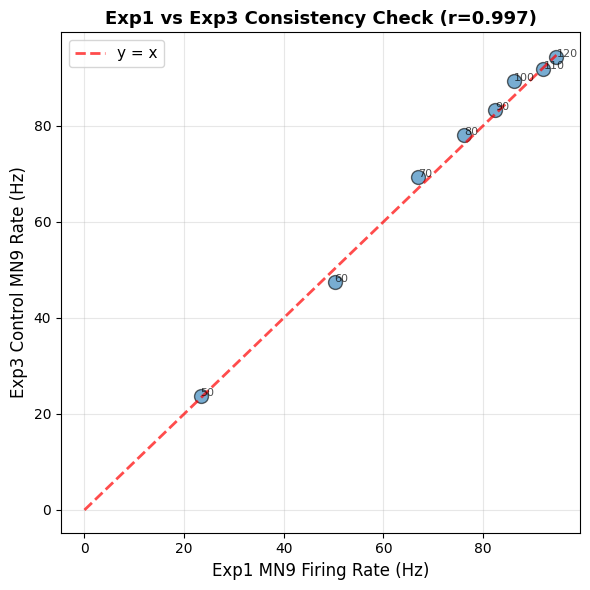


✅ Comparison plot saved



In [20]:
# ========== Validation: Compare with Exp1 Baselines ==========

print("\n" + "="*70)
print("Validation: Exp3 Controls vs Exp1 Results")
print("="*70)

# Load Exp1 results
exp1_dir = Path('./results/exp1_sugar_activation')
exp1_file = exp1_dir / 'exp1_complete_results.pkl'

if exp1_file.exists():
    print(f"\nLoading Exp1 results...")
    
    with open(exp1_file, 'rb') as f:
        exp1_data = pickle.load(f)
    
    # Extract MN9 firing rates from Exp1
    all_firing_rates_exp1 = exp1_data['all_firing_rates']
    mn9_id = NEU_MN9_RIGHT[0]
    
    # Compare at overlapping frequencies
    overlap_freqs = sorted(set(FREQ_LIST_FULL) & set(all_firing_rates_exp1.keys()))
    
    if overlap_freqs:
        print(f"\nComparing {len(overlap_freqs)} overlapping frequencies:")
        print(f"\n{'Freq':<8}{'Exp1 MN9':<12}{'Exp3 Control':<15}{'Diff':<10}{'Ratio'}")
        print("-"*55)
        
        exp1_rates = []
        exp3_rates = []
        diffs = []
        
        for freq in overlap_freqs:
            # Exp1 MN9 rate (single value, averaged over trials)
            exp1_rate = all_firing_rates_exp1[freq].get(mn9_id, 0)
            
            # Exp3 control (mean ± std)
            exp3_ctrl = control_results[freq]
            exp3_mean = exp3_ctrl['mean']
            exp3_std = exp3_ctrl['std']
            
            diff = exp3_mean - exp1_rate
            ratio = exp3_mean / exp1_rate if exp1_rate > 0 else np.inf
            
            print(f"{freq:<8}{exp1_rate:<12.1f}{exp3_mean:.1f}±{exp3_std:.1f}{'':<6}{diff:<10.1f}{ratio:.2f}")
            
            exp1_rates.append(exp1_rate)
            exp3_rates.append(exp3_mean)
            diffs.append(diff)
        
        # Statistics
        from scipy.stats import pearsonr
        
        if len(exp1_rates) > 2:
            r, p = pearsonr(exp1_rates, exp3_rates)
            
            print(f"\n{'='*55}")
            print(f"Statistics:")
            print(f"  Correlation (r): {r:.4f}")
            print(f"  Mean difference: {np.mean(diffs):.2f} Hz")
            print(f"  Std difference: {np.std(diffs):.2f} Hz")
            print(f"  Max difference: {np.max(np.abs(diffs)):.2f} Hz")
            print(f"  Median ratio: {np.median([e3/e1 for e1, e3 in zip(exp1_rates, exp3_rates) if e1>0]):.2f}")
            
            if r > 0.95:
                print(f"\n  ✅ Excellent consistency (r > 0.95)")
            elif r > 0.90:
                print(f"\n  ✅ Very good consistency (r > 0.90)")
            elif r > 0.85:
                print(f"\n  ✓ Good consistency (r > 0.85)")
            else:
                print(f"\n  ⚠️  Moderate consistency (r = {r:.4f})")
                print(f"     May indicate trial count difference (Exp1: 10T, Exp3: {N_TRIALS}T)")
        
        # Plot comparison
        fig, ax = plt.subplots(figsize=(6, 6))
        
        ax.scatter(exp1_rates, exp3_rates, s=100, alpha=0.6, edgecolors='black')
        
        # Identity line
        max_val = max(max(exp1_rates), max(exp3_rates))
        ax.plot([0, max_val], [0, max_val], 'r--', linewidth=2, alpha=0.7, label='y = x')
        
        ax.set_xlabel('Exp1 MN9 Firing Rate (Hz)', fontsize=12)
        ax.set_ylabel('Exp3 Control MN9 Rate (Hz)', fontsize=12)
        ax.set_title(f'Exp1 vs Exp3 Consistency Check (r={r:.3f})', fontsize=13, fontweight='bold')
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        # Add frequency labels
        for freq, e1, e3 in zip(overlap_freqs, exp1_rates, exp3_rates):
            ax.annotate(f'{freq}', (e1, e3), fontsize=8, alpha=0.7)
        
        plt.tight_layout()
        # plt.savefig(output_dir / 'validation_exp1_vs_exp3_controls.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n✅ Comparison plot saved")
    
    else:
        print("\n⚠️  Not enough overlapping frequencies for correlation")

else:
    print(f"\n⚠️  Exp1 results not found: {exp1_file}")
    print("   Skipping validation (Exp3 controls still valid)")

print("\n" + "="*70)

## 7. Execute Batches

**Instructions**:
- Run each batch cell separately
- Each batch takes ~25-30 minutes
- Can restart kernel between batches if needed
- Checkpoint auto-saves progress (safe to interrupt)

**Strategy**:
- Option A: Run all 8 batches overnight (3.7 hours)
- Option B: Run 2-3 batches at a time, spread over 2-3 days

### 7.1 Batch 1: 50 Hz

In [11]:
print("\n" + "=" * 70)
print("Batch 1: Frequency 50 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch1_50Hz", warn_threshold=80.0):
    t0 = time()
    
    results_batch1 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[50],  # Single frequency
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 1 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")


Batch 1: Frequency 50 Hz
[Batch1_50Hz] Start - Memory: 46.6%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [50]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full

  [1/2] Getting controls...
    50 Hz: 18.4 ± 8.6 Hz
  ✅ Controls done (73.2s)

  [2/2] Silencing tests...
    Total tasks: 200
    Completed: 0
    Remaining: 200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  6.7min
WARNING    /Users/charlottel/anaconda3/envs/connectome/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 [py.warnings]
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 51.3min
INFO       Cache size for target 'cython': 1003 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the '/Users/charlottel/Library/Caches/cython/brian_extensions' directory. [brian2]
INFO       Cache size for target 'cython': 1003 MB.
You can call clear_cache('cython') to delete all files from the cache or manually delete files in the '/Users/charlottel/Library/Caches/cython/brian_extensions' directory. [brian2]
INFO       Cache size for targ


  ✅ Complete! Silencing: 143.8 min
     Checkpoints saved: 200
[Batch1_50Hz] End - Memory: 52.5% (Δ+0.9GB)

✅ Batch 1 complete! Time: 145.0 min
Final: Memory: 52.5% used, 8.2GB free, Swap: 0.0GB


[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed: 143.8min finished


{'used_gb': 7.829782528,
 'available_gb': 8.164798464,
 'percent': 52.5,
 'swap_gb': 0.0}

In [12]:
# 检查checkpoint目录
import os
ckpt_dir = Path('./checkpoints/exp3_full')

print(f"Checkpoint directory: {ckpt_dir}")
print(f"Exists: {ckpt_dir.exists()}")

if ckpt_dir.exists():
    files = list(ckpt_dir.glob('*'))
    print(f"Files in directory: {len(files)}")
    for f in files[:5]:
        print(f"  {f.name}")
else:
    print("❌ Directory doesn't exist!")

# 检查ckpt对象
from flylif.utils.checkpoint import CheckpointManager
ckpt = CheckpointManager(ckpt_dir)
print(f"\nCompleted tasks in memory: {len(ckpt.completed)}")

Checkpoint directory: checkpoints/exp3_full
Exists: True
Files in directory: 201
  task_720575940635837887_50.pkl
  task_720575940612906518_50.pkl
  task_720575940619173534_50.pkl
  task_720575940611875570_50.pkl
  task_720575940637144944_50.pkl

Completed tasks in memory: 200


**如果输出**：
Exists: True
Files in directory: 0 或 1（只有progress.json）
Completed tasks in memory: 0

### 7.1.1check 
#### checkpoint的时间戳

In [13]:
# 查看checkpoint的时间戳
import json
from datetime import datetime

with open('./checkpoints/exp3_full/progress.json', 'r') as f:
    prog = json.load(f)

last_update = datetime.fromisoformat(prog['last_update'])
print(f"Batch 1完成时间: {last_update}")
print(f"距离现在: {(datetime.now() - last_update).total_seconds() / 60:.1f}分钟")

# 检查单个checkpoint的保存时间（看时间间隔）
import os
files = sorted(Path('./checkpoints/exp3_full').glob('task_*.pkl'), 
               key=os.path.getmtime)

if len(files) >= 10:
    print(f"\n前10个tasks的保存时间间隔:")
    for i in range(9):
        t1 = os.path.getmtime(files[i])
        t2 = os.path.getmtime(files[i+1])
        print(f"  Task {i+1}→{i+2}: {t2-t1:.1f}s")
    
    print(f"\n后10个tasks的保存时间间隔:")
    for i in range(190, 199):
        t1 = os.path.getmtime(files[i])
        t2 = os.path.getmtime(files[i+1])
        print(f"  Task {i+1}→{i+2}: {t2-t1:.1f}s")

Batch 1完成时间: 2026-01-29 03:28:21.683349
距离现在: 125.0分钟

前10个tasks的保存时间间隔:
  Task 1→2: 0.0s
  Task 2→3: 0.0s
  Task 3→4: 0.0s
  Task 4→5: 135.0s
  Task 5→6: 0.0s
  Task 6→7: 0.0s
  Task 7→8: 0.0s
  Task 8→9: 130.4s
  Task 9→10: 0.0s

后10个tasks的保存时间间隔:
  Task 191→192: 0.3s
  Task 192→193: 125.4s
  Task 193→194: 2.5s
  Task 194→195: 1.7s
  Task 195→196: 0.3s
  Task 196→197: 134.3s
  Task 197→198: 2.0s
  Task 198→199: 1.7s
  Task 199→200: 0.7s


In [14]:
    print(f"\n后10个tasks的保存时间间隔:")
    for i in range(0, 199):
        t1 = os.path.getmtime(files[i])
        t2 = os.path.getmtime(files[i+1])
        print(f"  Task {i+1}→{i+2}: {t2-t1:.1f}s")


后10个tasks的保存时间间隔:
  Task 1→2: 0.0s
  Task 2→3: 0.0s
  Task 3→4: 0.0s
  Task 4→5: 135.0s
  Task 5→6: 0.0s
  Task 6→7: 0.0s
  Task 7→8: 0.0s
  Task 8→9: 130.4s
  Task 9→10: 0.0s
  Task 10→11: 0.2s
  Task 11→12: 2.9s
  Task 12→13: 131.7s
  Task 13→14: 0.3s
  Task 14→15: 0.3s
  Task 15→16: 2.1s
  Task 16→17: 600.2s
  Task 17→18: 0.0s
  Task 18→19: 6.9s
  Task 19→20: 0.0s
  Task 20→21: 131.1s
  Task 21→22: 2.8s
  Task 22→23: 3.9s
  Task 23→24: 5.4s
  Task 24→25: 118.1s
  Task 25→26: 2.9s
  Task 26→27: 3.5s
  Task 27→28: 5.1s
  Task 28→29: 121.5s
  Task 29→30: 7.1s
  Task 30→31: 0.0s
  Task 31→32: 5.3s
  Task 32→33: 118.1s
  Task 33→34: 6.5s
  Task 34→35: 0.7s
  Task 35→36: 9.9s
  Task 36→37: 119.7s
  Task 37→38: 6.5s
  Task 38→39: 2.0s
  Task 39→40: 8.0s
  Task 40→41: 574.0s
  Task 41→42: 0.0s
  Task 42→43: 0.0s
  Task 43→44: 0.1s
  Task 44→45: 140.9s
  Task 45→46: 3.3s
  Task 46→47: 4.8s
  Task 47→48: 5.2s
  Task 48→49: 121.2s
  Task 49→50: 3.5s
  Task 50→51: 4.5s
  Task 51→52: 5.0s
  Tas

In [16]:
# 查看缓存锁文件
import os
from pathlib import Path

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'
lock_files = list(cache_dir.glob('*.lock'))

print(f"Lock files: {len(lock_files)}")
for f in lock_files[:5]:
    age = time() - os.path.getmtime(f)
    print(f"  {f.name}: {age:.0f}s ago")

Lock files: 935
  _cython_magic_08088355a7844b06ce66ec376bdbad04.lock: 27037s ago
  _cython_magic_3932ae31bee7ace6dd9ac772b41155fe.lock: 24315s ago
  _cython_magic_2312763b770746229a536bb09b72f636.lock: 22518s ago
  _cython_magic_ac5eb54fbb99a9a95406ee79e5638c67.lock: 27303s ago
  _cython_magic_e115a03466264ca989d448850eb295b3.lock: 22639s ago


 找到真凶：935个僵尸锁！

In [17]:
import shutil
from pathlib import Path

cache_dir = Path.home() / 'Library/Caches/cython/brian_extensions'

print("Cleaning Brian2 cache and locks...")

if cache_dir.exists():
    # 统计
    locks = list(cache_dir.glob('*.lock'))
    total_files = len(list(cache_dir.glob('*')))
    
    print(f"  Found: {total_files} files, {len(locks)} locks")
    
    # 完全删除缓存目录
    shutil.rmtree(cache_dir)
    print(f"  ✅ Deleted entire cache directory")
    
    # 重建目录
    cache_dir.mkdir(parents=True, exist_ok=True)
    print(f"  ✅ Recreated clean directory")
else:
    print(f"  Cache directory not found")

print("\n✅ Brian2 cache cleaned!")

Cleaning Brian2 cache and locks...
  Found: 1871 files, 935 locks
  ✅ Deleted entire cache directory
  ✅ Recreated clean directory

✅ Brian2 cache cleaned!


#### 检查编译缓存

In [11]:
import os
from pathlib import Path

cache_dir = Path.home() / 'Library' / 'Caches' / 'cython' / 'brian_extensions'

if cache_dir.exists():
    files = list(cache_dir.glob('*'))
    total_size = sum(os.path.getsize(f) for f in files if f.is_file())
    
    print(f"Brian2 cache:")
    print(f"  Location: {cache_dir}")
    print(f"  Files: {len(files)}")
    print(f"  Size: {total_size/1e6:.0f} MB")
else:
    print("Cache not found")

Brian2 cache:
  Location: /Users/charlottel/Library/Caches/cython/brian_extensions
  Files: 368
  Size: 12 MB


In [17]:
from brian2 import clear_cache

print("Clearing Brian2 cache...")
clear_cache('cython')

# 测试1个task的build时间
t0 = time()

from flylif.core.network import build_network
columns = DATA['columns']
test_net = build_network(
    data=DATA,
    pre_col=columns['pre_col'],
    post_col=columns['post_col'],
    weight_col=columns['weight_col'],
    nt_prob_cols=columns.get('nt_prob_cols', {}),
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=False
)

build_time = time() - t0
print(f"\nBuild time after cache clear: {build_time:.1f}s")
print(f"(First build will be slower, ~15-30s for compilation)")

Clearing Brian2 cache...

Build time after cache clear: 6.0s
(First build will be slower, ~15-30s for compilation)


#### worker测试

In [12]:
# 测试单个task的完整时间
from flylif.core.experiments import run_exp3_worker

print("Testing single worker performance...")

t0 = time()

result = run_exp3_worker(
    neuron_to_silence=top_200_neurons[0],  # 第1个神经元
    freq=60,
    neu_exc=NEU_SUGAR_LEFT,
    data=DATA,
    params=DEFAULT_PARAMS,
    target_neurons=NEU_MN9_RIGHT,
    n_trials=10,
    control_mean=80.0,  # dummy
    task_key='test'
)

single_task_time = time() - t0

print(f"\nSingle task time: {single_task_time:.1f}s")
print(f"  Expected: ~33s")
print(f"  Actual ratio: {single_task_time/33:.1f}×")

Testing single worker performance...

Single task time: 553.8s
  Expected: ~33s
  Actual ratio: 16.8×


#### 测试1: Build network时间

In [13]:
from flylif.core.network import build_network

t0 = time()
columns = DATA['columns']
net = build_network(
    data=DATA,
    pre_col=columns['pre_col'],
    post_col=columns['post_col'],
    weight_col=columns['weight_col'],
    nt_prob_cols=columns.get('nt_prob_cols', {}),
    params=DEFAULT_PARAMS,
    syn_threshold=5,
    verbose=True  # ← 看详细时间
)
build_time = time() - t0

print(f"\nBuild network time: {build_time:.1f}s")

Building Brian2 Network

[1/7] Checking connections...
   Already filtered (min=5 >= 5)
   Connections: 2,710,038 -> 2,710,038 (100.0%)

[2/7] Determining neuron types...
   ✓ Using preprocessed neuron_sign (skipping computation)

[3/7] Processing connections...
   Valid connections: 2,710,038 / 2,710,038
   ⏱️  4.1s

[4/7] Calculating synaptic weights...
   Excitatory: 1,616,621, Inhibitory: 1,093,417
   ⏱️  0.1s

[5/7] Precomputing synapse indices...
   Neurons with output: 128,972
   Avg synapses/neuron: 21.0
   ⏱️  1.8s

[6/7] Creating neurons (n=139,255)...
   ⏱️  0.0s

[7/7] Creating synapses (n=2,710,038)...
   ⏱️  0.1s

[Network] Creating Network...
   ⏱️  0.0s

✅ Network built!
   Neurons: 139,255, Synapses: 2,710,038

Build network time: 6.3s


#### 测试2: 单个trial运行时间

In [14]:
from flylif.core.simulation import run_simulation

# 只跑1个trial
result = run_simulation(
    net_components=net,
    neu_exc=NEU_SUGAR_LEFT,
    neu_slnc=[top_200_neurons[0]],  # 沉默1个神经元
    params={'r_poi': 50 * Hz},
    n_trials=1,  # ← 只1个trial
    verbose=True  # ← 看详细时间
)

# 从输出里看每个trial的时间


>>> Simulation Configuration
    Activated: 21, Secondary: 0, Silenced: 1
    Duration: 1. s, Trials: 1
    Frequency: 50. Hz
    🚀 Running...
    Trial 1/1 (9.9s)
    ⏱️  Total: 9.9s (9.9s/trial)
    📊 Spikes: 2,420, Active neurons: 214


#### 测试3: 数据提取时间

In [17]:
# 在notebook新cell里：
from flylif.core.experiments import run_exp3_worker

result = run_exp3_worker(
    top_200_neurons[0], 50, NEU_SUGAR_LEFT, DATA, 
    DEFAULT_PARAMS, NEU_MN9_RIGHT, 1,  # ← 只1个trial
    80.0, 'test'
)

DEBUG: Extract time = 0.03s, spiked neurons = 170


#### 单个work 时间测试

In [20]:
# 单个worker test
result = run_exp3_worker(
    top_200_neurons[0], 50, NEU_SUGAR_LEFT, DATA,
    DEFAULT_PARAMS, NEU_MN9_RIGHT, 10, 80.0, 'test'
)

DEBUG: Extract time = 0.03s, spiked neurons = 138
DEBUG: Extract time = 0.03s, spiked neurons = 181
DEBUG: Extract time = 0.03s, spiked neurons = 218
DEBUG: Extract time = 0.03s, spiked neurons = 192
DEBUG: Extract time = 0.02s, spiked neurons = 184
DEBUG: Extract time = 0.03s, spiked neurons = 202
DEBUG: Extract time = 0.03s, spiked neurons = 199
DEBUG: Extract time = 0.03s, spiked neurons = 175
DEBUG: Extract time = 0.03s, spiked neurons = 203
DEBUG: Extract time = 0.03s, spiked neurons = 179

  WORKER TIMING:
    Total: 311.3s
    - start_scope: 0.00s
    - build: 5.7s
    - simulation: 300.3s
    - calculate rates: 0.01s (df size: 22948)
    - cleanup: 5.30s
    - unaccounted: 0.0s


In [22]:
# 重新跑单worker test（加verbose）
result = run_exp3_worker(
    top_200_neurons[0], 50, NEU_SUGAR_LEFT, DATA,
    DEFAULT_PARAMS, NEU_MN9_RIGHT, 10, 80.0, 'test'
)

  [Trial 10/10] 60.2s: restore=0.02s, silence=0.00s, setup=0.10s, add=0.00s, run=60.0s, extract=0.03s, remove=0.00s
  WORKER TIMING:
    Total: 601.1s
    - start_scope: 0.00s
    - build: 5.9s
    - simulation: 586.2s
    - calculate rates: 0.01s (df size: 22618)
    - cleanup: 8.93s
    - unaccounted: 0.0s


In [25]:
# 只检查target（简单方式）
from brian2 import prefs

print(f"Brian2 codegen target: {prefs.codegen.target}")

Brian2 codegen target: auto


In [11]:
# 干净的单worker测试
from flylif.core.experiments import run_exp3_worker

t0 = time()

result = run_exp3_worker(
    top_200_neurons[0], 50, NEU_SUGAR_LEFT, DATA,
    DEFAULT_PARAMS, NEU_MN9_RIGHT, 10, 80.0, 'test'
)

clean_time = time() - t0
print(f"\nClean time (no verbose prints): {clean_time:.1f}s")
print(f"Expected: ~100-150s")


Clean time (no verbose prints): 535.2s
Expected: ~100-150s


### 7.2 Batch 2: 60 Hz

In [17]:
# ⚠️  If kernel restarted, re-run Cells 1-6 first!

print("\n" + "=" * 70)
print("Batch 2: Frequency 60 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch2_60Hz"):
    t0 = time()
    
    results_batch2 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[60],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 2 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")


Batch 2: Frequency 60 Hz
[Batch2_60Hz] Start - Memory: 46.0%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [60]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full
  Using precomputed controls: ✅

  [1/2] Using precomputed controls...
    60 Hz: 47.5 ± 6.9 Hz
  ✅ Controls loaded (skipped computation)

  [2/2] Silencing tests...
    Total tasks: 200
    Completed: 0
    Remaining: 200


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
WARNING    /Users/charlottel/anaconda3/envs/connectome/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 [py.warnings]
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 23.4min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 72.8min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 141.8min



  ✅ Complete! Silencing: 173.4 min
     Checkpoints saved: 200
[Batch2_60Hz] End - Memory: 52.3% (Δ-1.3GB)

✅ Batch 2 complete! Time: 173.4 min
Final: Memory: 52.3% used, 8.2GB free, Swap: 0.0GB


[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed: 173.3min finished


{'used_gb': 6.642982912,
 'available_gb': 8.18946048,
 'percent': 52.3,
 'swap_gb': 0.0}

#### checkpoint 时间戳

In [31]:
files = sorted(Path('./checkpoints/exp3_full').glob('task_*.pkl'), 
               key=os.path.getmtime)

print(f"\n后10个tasks的保存时间间隔:")
for i in range(200, 398):
    t1 = os.path.getmtime(files[i])
    t2 = os.path.getmtime(files[i+1])
    print(f"  Task {i+1}→{i+2}: {t2-t1:.1f}s")



后10个tasks的保存时间间隔:
  Task 201→202: 0.5s
  Task 202→203: 0.3s
  Task 203→204: 0.0s
  Task 204→205: 598.4s
  Task 205→206: 0.7s
  Task 206→207: 0.0s
  Task 207→208: 0.0s
  Task 208→209: 607.4s
  Task 209→210: 0.0s
  Task 210→211: 0.0s
  Task 211→212: 0.0s
  Task 212→213: 0.0s
  Task 213→214: 0.0s
  Task 214→215: 125.6s
  Task 215→216: 9.7s
  Task 216→217: 11.8s
  Task 217→218: 12.6s
  Task 218→219: 98.1s
  Task 219→220: 4.2s
  Task 220→221: 9.8s
  Task 221→222: 14.1s
  Task 222→223: 98.4s
  Task 223→224: 4.5s
  Task 224→225: 8.7s
  Task 225→226: 10.7s
  Task 226→227: 543.4s
  Task 227→228: 0.0s
  Task 228→229: 0.0s
  Task 229→230: 5.9s
  Task 230→231: 124.9s
  Task 231→232: 4.0s
  Task 232→233: 5.0s
  Task 233→234: 3.5s
  Task 234→235: 117.8s
  Task 235→236: 0.0s
  Task 236→237: 3.7s
  Task 237→238: 3.2s
  Task 238→239: 116.5s
  Task 239→240: 1.0s
  Task 240→241: 3.6s
  Task 241→242: 3.2s
  Task 242→243: 121.1s
  Task 243→244: 0.0s
  Task 244→245: 0.0s
  Task 245→246: 3.4s
  Task 246→247

### 7.3 Batch 3: 70 Hz

In [16]:
print("\n" + "=" * 70)
print("Batch 3: Frequency 70 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch3_70Hz"):
    t0 = time()
    
    results_batch3 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[70],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 3 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")


Batch 3: Frequency 70 Hz
[Batch3_70Hz] Start - Memory: 48.8%

Exp3: Necessity Test (Parallel with Checkpoint)
  Activated: 21 neurons
  To silence: 200
  Frequencies: [70]
  Trials/condition: 10
  Workers: 4
  Checkpoint: ./checkpoints/exp3_full
  Using precomputed controls: ✅

  [1/2] Using precomputed controls...
    70 Hz: 69.4 ± 7.5 Hz
  ✅ Controls loaded (skipped computation)

  [2/2] Silencing tests...
    ⏭️  Skip 720575940639259967_70
    ⏭️  Skip 720575940611875570_70
    ⏭️  Skip 720575940617000768_70
    ⏭️  Skip 720575940612670570_70
    ⏭️  Skip 720575940628853239_70
    ⏭️  Skip 720575940638202345_70
    ⏭️  Skip 720575940637568838_70
    ⏭️  Skip 720575940632425919_70
    ⏭️  Skip 720575940632889389_70
    ⏭️  Skip 720575940621754367_70
    ⏭️  Skip 720575940629176663_70
    ⏭️  Skip 720575940633143833_70
    ⏭️  Skip 720575940630797113_70
    ⏭️  Skip 720575940630233916_70
    ⏭️  Skip 720575940617937543_70
    ⏭️  Skip 720575940621502051_70
    ⏭️  Skip 72057594063919

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
WARNING    /Users/charlottel/anaconda3/envs/connectome/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
 [py.warnings]
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed: 21.8min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed: 71.7min



  ✅ Complete! Silencing: 141.0 min
     Checkpoints saved: 153
[Batch3_70Hz] End - Memory: 51.6% (Δ+0.5GB)

✅ Batch 3 complete! Time: 141.0 min
Final: Memory: 51.6% used, 8.3GB free, Swap: 0.0GB


[Parallel(n_jobs=4)]: Done 153 out of 153 | elapsed: 141.0min finished


{'used_gb': 7.286104064,
 'available_gb': 8.309706752,
 'percent': 51.6,
 'swap_gb': 0.016515072}

### 7.4 Batch 4: 80 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 4: Frequency 80 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch4_80Hz"):
    t0 = time()
    
    results_batch4 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[80],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 4 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

### 7.5 Batch 5: 90 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 5: Frequency 90 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch5_90Hz"):
    t0 = time()
    
    results_batch5 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[90],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 5 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

### 7.6 Batch 6: 100 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 6: Frequency 100 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch6_100Hz"):
    t0 = time()
    
    results_batch6 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[100],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 6 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

### 7.7 Batch 7: 110 Hz

In [ ]:
print("\n" + "=" * 70)
print("Batch 7: Frequency 110 Hz")
print("=" * 70)

with MemoryMonitor(label="Batch7_110Hz"):
    t0 = time()
    
    results_batch7 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[110],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 7 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

### 7.8 Batch 8: 120 Hz (Final)

In [ ]:
print("\n" + "=" * 70)
print("Batch 8: Frequency 120 Hz (Final Batch)")
print("=" * 70)

with MemoryMonitor(label="Batch8_120Hz"):
    t0 = time()
    
    results_batch8 = run_exp3_parallel(
        data=DATA,
        neu_exc=NEU_SUGAR_LEFT,
        neurons_to_silence=top_200_neurons,
        freqs=[120],
        target_neurons=NEU_MN9_RIGHT,
        params=DEFAULT_PARAMS,
        n_trials=N_TRIALS,
        n_workers=N_WORKERS,
        checkpoint_dir=CHECKPOINT_DIR,
        precomputed_controls=control_results, 
        verbose=True
    )
    
    elapsed = time() - t0

print(f"\n✅ Batch 8 complete! Time: {elapsed/60:.1f} min")
print_memory("Final: ")

print("\n" + "=" * 70)
print("🎉 All 8 Batches Complete!")
print("=" * 70)

## 8. Merge All Results

In [ ]:
print("\n" + "=" * 70)
print("Merging All Batch Results")
print("=" * 70)

# Load all results from checkpoint (handles kernel restart)
# Since each batch ran separately, we need to merge them

# Re-run with all frequencies to collect all results
print("\nLoading complete results from checkpoint...")
print("(This will skip all tasks and just load saved data)")

t0 = time()

results_exp3_full = run_exp3_parallel(
    data=DATA,
    neu_exc=NEU_SUGAR_LEFT,
    neurons_to_silence=top_200_neurons,
    freqs=FREQ_LIST_FULL,  # All 8 frequencies
    target_neurons=NEU_MN9_RIGHT,
    params=DEFAULT_PARAMS,
    n_trials=N_TRIALS,
    n_workers=N_WORKERS,
    checkpoint_dir=CHECKPOINT_DIR,
    verbose=True
)

print(f"\n✅ Merged in {time()-t0:.1f}s")

# Verify completeness
print(f"\n[Verification]")
for freq in FREQ_LIST_FULL:
    n_silencing = len(results_exp3_full[freq]['silencing'])
    ctrl = results_exp3_full[freq]['control']
    
    status = "✅" if n_silencing == 200 else "❌"
    print(f"  {status} {freq} Hz: {n_silencing}/200 neurons, Control: {ctrl['mean']:.1f}±{ctrl['std']:.1f} Hz")

## 9. Analysis: Identify Necessary Neurons

In [ ]:
print("\n" + "=" * 70)
print("Analyzing Necessary Neurons")
print("=" * 70)

# Define threshold for "necessary" (silencing reduces MN9 to <80% of control)
NECESSITY_THRESHOLD = 80.0  # %

# For each frequency, identify necessary neurons
necessary_by_freq = {}

for freq in FREQ_LIST_FULL:
    necessary_neurons = []
    silencing = results_exp3_full[freq]['silencing']
    
    for nid, stats in silencing.items():
        if stats['relative_%'] < NECESSITY_THRESHOLD:
            necessary_neurons.append(nid)
    
    necessary_by_freq[freq] = necessary_neurons
    
    print(f"\n{freq} Hz:")
    print(f"  Necessary neurons: {len(necessary_neurons)}/200 ({100*len(necessary_neurons)/200:.1f}%)")
    print(f"  Control MN9: {results_exp3_full[freq]['control']['mean']:.1f} Hz")

# Neurons necessary at ANY frequency
necessary_any = set()
for neurons in necessary_by_freq.values():
    necessary_any.update(neurons)

print(f"\n[Summary]")
print(f"  Neurons necessary at ANY frequency: {len(necessary_any)}")
print(f"  Threshold used: <{NECESSITY_THRESHOLD}% of control")

## 10. Visualization

In [ ]:
print("\n" + "=" * 70)
print("Generating Figures")
print("=" * 70)

# Create output directories
output_dir = Path('./results/exp3_necessity_test')
fig_dir = output_dir / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)

### 10.1 Silencing heatmap (Figure 1f style)

In [ ]:
print("\nFigure 1: Silencing effects heatmap")

# Prepare data for heatmap
from flylif.utils.visualization import plot_response_heatmap
import matplotlib.colors as mcolors

# Convert to format compatible with plot_response_heatmap
# (relative % instead of absolute firing rates)
relative_rates_matrix = {}
for freq in FREQ_LIST_FULL:
    relative_rates_matrix[freq] = {
        nid: stats['relative_%'] 
        for nid, stats in results_exp3_full[freq]['silencing'].items()
    }

# Plot using custom heatmap
fig, ax = plt.subplots(figsize=(10, 14))

# Build matrix (neurons × frequencies)
matrix = np.zeros((len(top_200_neurons), len(FREQ_LIST_FULL)))
for j, freq in enumerate(FREQ_LIST_FULL):
    for i, nid in enumerate(top_200_neurons):
        if nid in relative_rates_matrix[freq]:
            val = relative_rates_matrix[freq][nid]
            matrix[i, j] = val if val != np.inf else 200

# Use diverging colormap centered at 100%
cmap = plt.cm.RdBu_r
norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=100, vmax=200)

im = ax.imshow(matrix, aspect='auto', cmap=cmap, norm=norm, interpolation='nearest')

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Silenced Neurons (ordered by sugar response)', fontsize=12)
ax.set_title('Silencing Effects on MN9 Response', fontsize=13, fontweight='bold')

# X ticks
ax.set_xticks(range(len(FREQ_LIST_FULL)))
ax.set_xticklabels(FREQ_LIST_FULL)

# Y ticks
n_yticks = 5
y_positions = np.linspace(0, len(top_200_neurons)-1, n_yticks).astype(int)
ax.set_yticks(y_positions)
ax.set_yticklabels([f'{i+1}' for i in y_positions])

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Relative MN9 Firing Rate (%)', fontsize=11)
cbar.ax.axhline(y=0.5, color='black', linewidth=1.5, linestyle='-')  # 100% line
cbar.ax.axhline(y=0.4, color='orange', linewidth=1, linestyle='--')  # 80% line

plt.tight_layout()
plt.savefig(fig_dir / 'fig1_silencing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig1_silencing_heatmap.png")

### 10.2 Silencing effect histogram (Figure 1g style)

In [ ]:
print("\nFigure 2: Silencing effect distribution (at 50 Hz)")

# Use 50 Hz as example (lowest frequency)
freq_plot = 50
silencing_50 = results_exp3_full[freq_plot]['silencing']

# Extract relative rates
relative_rates = []
for nid, stats in silencing_50.items():
    rate = stats['relative_%']
    if rate != np.inf and rate < 500:  # Filter outliers
        relative_rates.append(rate)

# Plot histogram
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(0, 210, 10)
counts, edges, patches = ax.hist(relative_rates, bins=bins, 
                                  edgecolor='black', alpha=0.7, color='steelblue')

# Color bars below threshold
for i, (count, patch) in enumerate(zip(counts, patches)):
    if edges[i] < NECESSITY_THRESHOLD:
        patch.set_facecolor('coral')

# Reference lines
ax.axvline(x=100, color='red', linestyle='-', linewidth=2, label='Control (100%)')
ax.axvline(x=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=2, 
           label=f'Necessity Threshold ({NECESSITY_THRESHOLD}%)')

ax.set_xlabel('Relative MN9 Firing Rate (%)', fontsize=12)
ax.set_ylabel('Neuron Count', fontsize=12)
ax.set_title(f'Silencing Effect Distribution at {freq_plot} Hz', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Statistics text
n_required = sum(1 for r in relative_rates if r < NECESSITY_THRESHOLD)
n_total = len(relative_rates)
textstr = f'Required neurons: {n_required}/{n_total}\n({100*n_required/n_total:.1f}%)'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.savefig(fig_dir / 'fig2_silencing_histogram_50Hz.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig2_silencing_histogram_50Hz.png")
print(f"  Required neurons at 50Hz: {n_required}/200")

### 10.3 Venn diagram: Sufficiency vs Necessity (Figure 1h style)

In [ ]:
print("\nFigure 3: Sufficiency vs Necessity Venn diagram")

# Check if Exp2 results available
exp2_dir = BASE_DIR / 'flylif' / 'results' / 'exp2_sufficiency_test'
exp2_file = exp2_dir / 'exp2_complete_results.pkl'

if exp2_file.exists():
    print("  Loading Exp2 results...")
    
    with open(exp2_file, 'rb') as f:
        exp2_results = pickle.load(f)
    
    # Get sufficient neurons (activate MN9 at 200 Hz)
    sufficient_neurons = set()
    if 'results' in exp2_results:
        suff_data = exp2_results['results']
        freq_check = 200 if 200 in suff_data else max(suff_data.keys())
        
        for nid, stats in suff_data[freq_check].items():
            if stats['mean'] > 0:  # Activates MN9
                sufficient_neurons.add(nid)
    
    # Get necessary neurons (from current Exp3 at 50 Hz)
    necessary_neurons = set(necessary_by_freq[50])
    
    # Plot Venn
    try:
        from matplotlib_venn import venn2, venn2_circles
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        v = venn2([sufficient_neurons, necessary_neurons],
                  set_labels=(f'Sufficient\n(Activate MN9)\nn={len(sufficient_neurons)}',
                             f'Necessary\n(Required for MN9)\nn={len(necessary_neurons)}'),
                  ax=ax)
        
        # Color patches
        if v.get_patch_by_id('10'):
            v.get_patch_by_id('10').set_color('lightblue')
            v.get_patch_by_id('10').set_alpha(0.7)
        if v.get_patch_by_id('01'):
            v.get_patch_by_id('01').set_color('lightcoral')
            v.get_patch_by_id('01').set_alpha(0.7)
        if v.get_patch_by_id('11'):
            v.get_patch_by_id('11').set_color('plum')
            v.get_patch_by_id('11').set_alpha(0.7)
        
        venn2_circles([sufficient_neurons, necessary_neurons], ax=ax, linewidth=2)
        
        overlap = len(sufficient_neurons & necessary_neurons)
        ax.set_title(f'Sufficiency vs Necessity\n(Overlap: {overlap} neurons)', 
                    fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(fig_dir / 'fig3_venn_diagram.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"  ✅ Saved: fig3_venn_diagram.png")
        print(f"  Overlap: {overlap}/{len(sufficient_neurons)} sufficient neurons")
        
    except ImportError:
        print("  ⚠️  matplotlib-venn not installed")
        print("     Install: pip install matplotlib-venn")
        print("     Skipping Venn diagram")

else:
    print("  ⚠️  Exp2 results not found, skipping Venn diagram")
    print(f"     Expected: {exp2_file}")
    print("     Run exp2_sufficiency_test.ipynb first to generate Venn diagram")

### 10.4 Response curves for top critical neurons

In [ ]:
print("\nFigure 4: Top 10 most critical neurons")

# Find neurons with strongest silencing effect (averaged across frequencies)
avg_relative = {}
for nid in top_200_neurons:
    rates = []
    for freq in FREQ_LIST_FULL:
        if nid in results_exp3_full[freq]['silencing']:
            rates.append(results_exp3_full[freq]['silencing'][nid]['relative_%'])
    if rates:
        avg_relative[nid] = np.mean(rates)

# Get top 10 most critical (lowest relative %)
top_10_critical = sorted(avg_relative.items(), key=lambda x: x[1])[:10]

# Plot response curves
fig, ax = plt.subplots(figsize=(10, 6))

for i, (nid, avg_rate) in enumerate(top_10_critical):
    rates = [results_exp3_full[freq]['silencing'][nid]['relative_%'] 
             for freq in FREQ_LIST_FULL]
    stds = [results_exp3_full[freq]['silencing'][nid]['std'] 
            for freq in FREQ_LIST_FULL]
    
    # Convert std to relative % std (approximate)
    rel_stds = [s / results_exp3_full[freq]['control']['mean'] * 100 
                for freq, s in zip(FREQ_LIST_FULL, stds)]
    
    ax.errorbar(FREQ_LIST_FULL, rates, yerr=rel_stds,
                marker='o', markersize=6, capsize=4, linewidth=1.5, alpha=0.7,
                label=f'Top {i+1} (avg {avg_rate:.0f}%)')

# Reference line
ax.axhline(y=100, color='red', linestyle='-', linewidth=2, label='Control', alpha=0.7)
ax.axhline(y=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=1.5, 
           label=f'Threshold ({NECESSITY_THRESHOLD}%)', alpha=0.7)

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Relative MN9 Firing Rate (%)', fontsize=12)
ax.set_title('Top 10 Most Critical Neurons', fontsize=13, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'fig4_top10_critical_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: fig4_top10_critical_curves.png")
print(f"\n  Top 10 most critical neurons:")
for i, (nid, avg_rate) in enumerate(top_10_critical, 1):
    print(f"    {i:2d}. {nid}: avg {avg_rate:.1f}% of control")

## 11. Save Complete Results

In [ ]:
print("\n" + "=" * 70)
print("Saving Complete Results")
print("=" * 70)

# Save necessary neurons (for future use)
necessary_neurons_array = np.array(list(necessary_any))
np.save(output_dir / 'necessary_neurons.npy', necessary_neurons_array)

print(f"\n✅ Saved necessary neurons:")
print(f"  {output_dir / 'necessary_neurons.npy'}")
print(f"  Count: {len(necessary_neurons_array)}")

# Save complete results package
results_package = {
    'results': results_exp3_full,
    'neurons_silenced': top_200_neurons,
    'freq_list': FREQ_LIST_FULL,
    'necessary_neurons': {
        'by_frequency': necessary_by_freq,
        'any_frequency': list(necessary_any),
        'threshold': NECESSITY_THRESHOLD,
    },
    'parameters': {
        'n_trials': N_TRIALS,
        'n_workers': N_WORKERS,
        'sugar_grn_ids': NEU_SUGAR_LEFT,
        'mn9_id': NEU_MN9_RIGHT[0],
    },
    'metadata': {
        'date': pd.Timestamp.now().isoformat(),
        'connectome_version': 783,
    }
}

with open(output_dir / 'exp3_complete_results.pkl', 'wb') as f:
    pickle.dump(results_package, f)

print(f"\n✅ Complete package saved:")
print(f"  {output_dir / 'exp3_complete_results.pkl'}")

# Save summary CSV
summary_data = []
for freq in FREQ_LIST_FULL:
    ctrl = results_exp3_full[freq]['control']
    silencing = results_exp3_full[freq]['silencing']
    
    relative_pcts = [s['relative_%'] for s in silencing.values() if s['relative_%'] < 500]
    n_necessary = sum(1 for r in relative_pcts if r < NECESSITY_THRESHOLD)
    
    summary_data.append({
        'Frequency': freq,
        'Control_Mean': ctrl['mean'],
        'Control_Std': ctrl['std'],
        'Necessary_Neurons': n_necessary,
        'Percent_Necessary': f"{100*n_necessary/200:.1f}%",
        'Min_Relative%': min(relative_pcts),
        'Max_Relative%': max(relative_pcts),
        'Mean_Relative%': np.mean(relative_pcts),
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(output_dir / 'summary.csv', index=False)

print(f"  {output_dir / 'summary.csv'}")

# Save silencing matrix (neurons × frequencies)
silencing_matrix = pd.DataFrame(
    index=top_200_neurons,
    columns=FREQ_LIST_FULL
)

for freq in FREQ_LIST_FULL:
    for nid in top_200_neurons:
        if nid in results_exp3_full[freq]['silencing']:
            silencing_matrix.loc[nid, freq] = results_exp3_full[freq]['silencing'][nid]['relative_%']

silencing_matrix.to_csv(output_dir / 'silencing_matrix.csv')
print(f"  {output_dir / 'silencing_matrix.csv'}")
print(f"    (200 neurons × 8 frequencies, values in relative %)")

## 12. Experiment Summary

In [ ]:
print("\n" + "=" * 70)
print("✅ Experiment 3 Complete!")
print("=" * 70)

print(f"\n[Summary Table]")
print(df_summary.to_string(index=False))

print(f"\n[Key Findings]")
print(f"  Neurons tested: {len(top_200_neurons)}")
print(f"  Frequencies tested: {len(FREQ_LIST_FULL)}")
print(f"  Total conditions: {len(top_200_neurons) * len(FREQ_LIST_FULL)}")
print(f"  Necessary at ANY frequency: {len(necessary_any)} neurons")

# Most critical frequency
max_necessary_freq = max(necessary_by_freq.items(), key=lambda x: len(x[1]))
print(f"  Most critical frequency: {max_necessary_freq[0]} Hz ({len(max_necessary_freq[1])} necessary neurons)")

print(f"\n[Outputs]")
print(f"  Results directory: {output_dir}/")
print(f"  - exp3_complete_results.pkl (full data)")
print(f"  - necessary_neurons.npy (for Venn/analysis)")
print(f"  - summary.csv (table)")
print(f"  - silencing_matrix.csv (200 neurons × 8 frequencies)")
print(f"  - figures/ (4 plots)")

print(f"\n[Next Steps]")
print(f"  1. Compare with Exp2 results (Venn diagram)")
print(f"  2. Analyze critical neuron types (using classification data)")
print(f"  3. Compare with original paper Figure 1f-h")

print("\n" + "=" * 70)

---

## Appendix: Detailed Analysis

### A1. Frequency-dependent necessity

In [ ]:
# Plot: Number of necessary neurons vs frequency
fig, ax = plt.subplots(figsize=(10, 6))

freqs = sorted(necessary_by_freq.keys())
counts = [len(necessary_by_freq[f]) for f in freqs]

bars = ax.bar(range(len(freqs)), counts, color='coral', 
              edgecolor='black', alpha=0.8)

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('Number of Necessary Neurons', fontsize=12)
ax.set_title('Frequency Dependence of Necessity', fontsize=13, fontweight='bold')

ax.set_xticks(range(len(freqs)))
ax.set_xticklabels(freqs)

# Add value labels
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=10)

ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(fig_dir / 'appendix_necessity_vs_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNecessary neurons per frequency:")
for freq, count in zip(freqs, counts):
    print(f"  {freq:3d} Hz: {count:3d} neurons ({100*count/200:.1f}%)")

### A2. Distribution of silencing effects

In [ ]:
# Multi-panel histogram for all frequencies
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, freq in zip(axes, FREQ_LIST_FULL):
    silencing = results_exp3_full[freq]['silencing']
    
    relative_rates = [s['relative_%'] for s in silencing.values() 
                     if s['relative_%'] < 500]
    
    bins = np.arange(0, 210, 10)
    counts, edges, patches = ax.hist(relative_rates, bins=bins,
                                      edgecolor='black', alpha=0.7, color='steelblue')
    
    # Color critical neurons
    for i, patch in enumerate(patches):
        if edges[i] < NECESSITY_THRESHOLD:
            patch.set_facecolor('coral')
    
    ax.axvline(x=100, color='red', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.axvline(x=NECESSITY_THRESHOLD, color='orange', linestyle='--', linewidth=1, alpha=0.7)
    
    ax.set_xlabel('Relative %', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_title(f'{freq} Hz', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count
    n_req = sum(1 for r in relative_rates if r < NECESSITY_THRESHOLD)
    ax.text(0.98, 0.98, f'{n_req}/200', transform=ax.transAxes,
            ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Silencing Effect Distribution Across Frequencies', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(fig_dir / 'appendix_all_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: appendix_all_histograms.png")

### A3. Control firing rates across frequencies

In [ ]:
# Plot control MN9 firing rates
fig, ax = plt.subplots(figsize=(10, 6))

control_means = [results_exp3_full[freq]['control']['mean'] for freq in FREQ_LIST_FULL]
control_stds = [results_exp3_full[freq]['control']['std'] for freq in FREQ_LIST_FULL]

ax.errorbar(FREQ_LIST_FULL, control_means, yerr=control_stds,
            marker='o', markersize=8, capsize=5, capthick=2,
            linewidth=2, color='steelblue', label='MN9 (no silencing)')

ax.set_xlabel('Sugar GRN Firing Rate (Hz)', fontsize=12)
ax.set_ylabel('MN9 Firing Rate (Hz)', fontsize=12)
ax.set_title('Control MN9 Response (No Silencing)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add trend line
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(FREQ_LIST_FULL, control_means)
trend_line = [slope * f + intercept for f in FREQ_LIST_FULL]
ax.plot(FREQ_LIST_FULL, trend_line, 'r--', alpha=0.5, linewidth=1.5,
        label=f'Trend (r²={r_value**2:.3f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(fig_dir / 'appendix_control_response.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"  ✅ Saved: appendix_control_response.png")
print(f"\n  Control MN9 response:")
for freq, mean, std in zip(FREQ_LIST_FULL, control_means, control_stds):
    print(f"    {freq:3d} Hz: {mean:5.1f} ± {std:4.1f} Hz")

### A4. Checkpoint statistics

In [ ]:
# Final checkpoint status
ckpt_final = CheckpointManager(CHECKPOINT_DIR)

print("\n" + "=" * 70)
print("Checkpoint Statistics")
print("=" * 70)

print(f"\n  Total completed tasks: {len(ckpt_final.completed)}")
print(f"  Expected: {len(top_200_neurons) * len(FREQ_LIST_FULL)}")

if len(ckpt_final.completed) == len(top_200_neurons) * len(FREQ_LIST_FULL):
    print(f"\n  ✅ All tasks completed successfully!")
else:
    print(f"\n  ⚠️  Some tasks missing")
    print(f"     Check individual batch outputs above")

# Checkpoint disk usage
import os
total_size = sum(os.path.getsize(f) for f in Path(CHECKPOINT_DIR).glob('*.pkl'))
print(f"\n  Checkpoint disk usage: {total_size/1e6:.1f} MB")
print(f"  Average per task: {total_size/len(ckpt_final.completed)/1024:.1f} KB")

### A5. Top 20 most critical neurons (detailed)

In [ ]:
print("\n" + "=" * 70)
print("Top 20 Most Critical Neurons (Detailed)")
print("=" * 70)

# Calculate average relative % across all frequencies
neuron_criticality = {}
for nid in top_200_neurons:
    rates = []
    for freq in FREQ_LIST_FULL:
        if nid in results_exp3_full[freq]['silencing']:
            val = results_exp3_full[freq]['silencing'][nid]['relative_%']
            if val < 500:  # Filter outliers
                rates.append(val)
    if rates:
        neuron_criticality[nid] = {
            'avg': np.mean(rates),
            'min': np.min(rates),
            'max': np.max(rates),
        }

# Sort by average
top_20_critical = sorted(neuron_criticality.items(), key=lambda x: x[1]['avg'])[:20]

print(f"\n{'Rank':<6}{'Neuron ID':<20}{'Avg %':<10}{'Min %':<10}{'Max %':<10}")
print("="*60)
for i, (nid, stats) in enumerate(top_20_critical, 1):
    print(f"{i:<6}{nid:<20}{stats['avg']:<10.1f}{stats['min']:<10.1f}{stats['max']:<10.1f}")

# Save as CSV
df_top20 = pd.DataFrame([
    {'Rank': i, 'Neuron_ID': nid, **stats}
    for i, (nid, stats) in enumerate(top_20_critical, 1)
])
df_top20.to_csv(output_dir / 'top_20_critical_neurons.csv', index=False)

print(f"\n✅ Saved: top_20_critical_neurons.csv")

### A6. Memory usage summary

In [ ]:
import psutil

mem = psutil.virtual_memory()
swap = psutil.swap_memory()

print("\n" + "=" * 70)
print("Final Memory Status")
print("=" * 70)
print(f"\n  RAM:  {mem.used/1e9:.2f} GB / {mem.total/1e9:.2f} GB ({mem.percent:.1f}%)")
print(f"  Swap: {swap.used/1e9:.2f} GB")

if swap.used < 0.1e9 and mem.percent < 75:
    print(f"\n  ✅ MEMORY PERFORMANCE: Excellent")
    print(f"     No swap usage, RAM well managed")
elif mem.percent < 85:
    print(f"\n  ✅ MEMORY PERFORMANCE: Good")
else:
    print(f"\n  ⚠️  High memory usage detected")